In [30]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmasher as cmr
import matplotlib.colors as clrs
import matplotlib.cm as cmap
import matplotlib.pylab as pylab
from scipy.special import sph_harm
from scipy.integrate import nquad
from scipy.optimize import root
from mpmath import polylog
from scipy.interpolate import interp1d




colors = ['#8a1f1f','#79a43a','#C59D34','#171782', '#cf6717','#ad6faa',
          '#009999','#828282']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['axes.linewidth'] = 2.

# Load plot style

# from plot_params import params
# pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Tick tweaks 

from matplotlib import ticker

/var/folders/c_/m9xq6z1d7ng4l884vymz4c240000gq/T/ipykernel_61167/3721545370.py:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


# Check a spectrum

In [64]:
# Paths to your files
# file_path = '/Users/andreacaputo/Dropbox/Mac (2)/Desktop/PhysicsFolder/eRositaXray/Spectra_irfs_v3/LMC_TM1_pha.fits'
# rmf_path = '/Users/andreacaputo/Dropbox/Mac (2)/Desktop/PhysicsFolder/eRositaXray/Spectra_irfs_v3/tm1_rmf_141103v02.fits'
file_path = '/Users/mnegro/MyDocuments/XRAY_PROBE/eROSITA/LMC_DR1/LMCspectra/LMC_TM1_pha.fits'
rmf_path = '/Users/mnegro/MyDocuments/XRAY_PROBE/eROSITA/LMC_DR1/LMCspectra/tm1_rmf_141103v02.fits'

# Load the FITS file
hdul = fits.open(file_path)
spectrum_hdu = hdul['SPECTRUM']
spectrum_data = Table(spectrum_hdu.data)

# Load the RMF file
rmf_hdul = fits.open(rmf_path)
ebounds = Table(rmf_hdul['EBOUNDS'].data)
matrix = Table(rmf_hdul[1].data)

# Extract energy bounds from RMF
energy_lo = ebounds['E_MIN']
energy_hi = ebounds['E_MAX']
energy_bins = np.concatenate((energy_lo, [energy_hi[-1]]))

# Calculate the bin widths, which we will use to convert the y-axis
bin_widths = np.diff(energy_bins)

# Convert channels to energies using the EBOUNDS
channel = spectrum_data['CHANNEL']
rate = spectrum_data['RATE']

# Get energy corresponding to each channel
energies = 0.5 * (energy_lo + energy_hi)

# Normalize the rate by the bin width to get counts/keV/s
rate_per_keV = rate / bin_widths

# Plot the converted spectrum
plt.figure()
plt.plot(energies, rate_per_keV, drawstyle='steps-mid')
plt.xlabel('Energy (keV)')
plt.ylabel('Rate (counts/keV/s)')
plt.title('Spectrum')
plt.show()



KeyError: "Extension 'MATRIX' not found."

# Interpolating corresponding ARF

In [39]:
# Load the ARF file
arf_file = '/Users/mnegro/MyDocuments/XRAY_PROBE/eROSITA/LMC_DR1/LMCspectra/tm1_arf_filter_000101v02.fits'

with fits.open(arf_file) as hdul:
    arf_data = hdul[1].data
    energ_lo = arf_data['ENERG_LO']
    energ_hi = arf_data['ENERG_HI']
    specrel = arf_data['SPECRESP']

# Calculate the energy midpoints
energy_midpoints = 0.5 * (energ_lo + energ_hi)

# Create the interpolated ARF function
arf_interpolated = interp1d(energy_midpoints, specrel, bounds_error=False, fill_value="extrapolate")


# Now the response matrix

In [40]:
# rmf_path = '/Users/andreacaputo/Dropbox/Mac (2)/Desktop/PhysicsFolder/eRositaXray/Spectra_irfs_v3/tm1_rmf_141103v02.fits'

# Load the RMF file
rmf_hdul = fits.open(rmf_path)
ebounds = Table(rmf_hdul['EBOUNDS'].data)
matrix = Table(rmf_hdul['MATRIX'].data) # the response matrix, how photons are redistributed in energy by the detector.



In [54]:
def ResponseDetector(E_i, photons):
    
    # Find the appropriate row in the MATRIX extension for the given energy E_i
    energy_lo = matrix['ENERG_LO']
    energy_hi = matrix['ENERG_HI']
    energy_bin_index = np.where((energy_lo <= E_i) & (E_i < energy_hi))[0][0]
    
    # Get the response data for the identified energy bin
    start_chan = matrix['F_CHAN'][energy_bin_index][0]
    print(matrix['F_CHAN'])
    num_chans = matrix['N_CHAN'][energy_bin_index][0]
    end_chan = start_chan + num_chans - 1
    matrix_vals = matrix['MATRIX'][energy_bin_index][:num_chans]
    print('matrix vals', matrix_vals)
    
    # Spread the photons across the channels
    photons_detector = photons * matrix_vals 
    
    # Extract the mean energy for each affected channel
    e_min = ebounds['E_MIN'][start_chan:end_chan + 1]
    e_max = ebounds['E_MAX'][start_chan:end_chan + 1]
    affected_channel_energies = 0.5 * (e_min + e_max)
    
    return affected_channel_energies, photons_detector

# This function uses the ResponseDetector function for multiple incident energies and photon counts

def AggregateResponse(E_i_arr, photons_arr):
    
    total_photons = {}

    for E_i, photons in zip(E_i_arr, photons_arr):
        energies, photon_counts = ResponseDetector(E_i, photons)
        
        for energy, count in zip(energies, photon_counts):
            if energy in total_photons:
                total_photons[energy] += count
            else:
                total_photons[energy] = count
    
    affected_channel_energies = np.array(list(total_photons.keys()))
    total_photons_detector = np.array(list(total_photons.values()))
    
    # Sort by energy
    sorted_indices = np.argsort(affected_channel_energies)
    affected_channel_energies = affected_channel_energies[sorted_indices]
    total_photons_detector = total_photons_detector[sorted_indices]
    
    # Calculate the width of each energy bin and convert to counts/s/keV
    bin_widths = np.diff(np.append(affected_channel_energies, affected_channel_energies[-1]))
    bin_widths = np.where(bin_widths == 0, np.nan, bin_widths) # Ensure no division by zero and handle potential nan values
    total_photons_detector = np.nan_to_num(total_photons_detector / bin_widths)
    
    return affected_channel_energies, total_photons_detector

# As above but without the conversion to counts/s/keV. It just sums the photon counts.

def AggregateResponse2(E_i_arr, photons_arr):
    total_photons = {}

    for E_i, photons in zip(E_i_arr, photons_arr):
        energies, photon_counts = ResponseDetector(E_i, photons)
        
        for energy, count in zip(energies, photon_counts):
            if energy in total_photons:
                total_photons[energy] += count
            else:
                total_photons[energy] = count
    
    affected_channel_energies = np.array(list(total_photons.keys()))
    total_photons_detector = np.array(list(total_photons.values()))
    
    # Sort by energy
    sorted_indices = np.argsort(affected_channel_energies)
    affected_channel_energies = affected_channel_energies[sorted_indices]
    total_photons_detector = total_photons_detector[sorted_indices]
      
    return affected_channel_energies, total_photons_detector

In [61]:
# from rmf import xEnergyDispersion

# rmf_path = '/Users/mnegro/MyDocuments/XRAY_PROBE/eROSITA/LMC_DR1/LMCspectra/tm1_rmf_141103v02.rmf'
# # rmf_path = '/Users/mnegro/MyDocuments/XRAY_PROBE/eROSITA/LMC_DR1/LMCspectra/ixpe_d2_obssim_v011.rmf'

# irf_rmf = xEnergyDispersion(rmf_path)
# irf_rmf.plot()

# Try to play with some astro model

We start with a black body function 

$\mathcal{B}(E, T, K) = \frac{K \, E^2}{(e^{E/T}-1) \, T^4}$

with normalisation factor $K$ and temperature T. I started with this just to see that my functions are working, then one can apply this to whatever model. 

In [25]:
def bbody(E, kT, K):
    
    """
    Calculate the blackbody spectrum.

    K: Normalization factor.
    E is the energy in keV and also kT the temperature in keV

    Returns:
    array-like: Blackbody spectrum (photon flux density) in photons/cm^2/s/keV.
    """
    # Planck's law for photon flux density
    factor = 8.0525
    exponent = np.exp(E / kT) - 1
    spectrum = K * factor * (E**2) / (kT**4 * exponent)
    
    return spectrum

(0.0, 3.0, 0.0, 0.06)

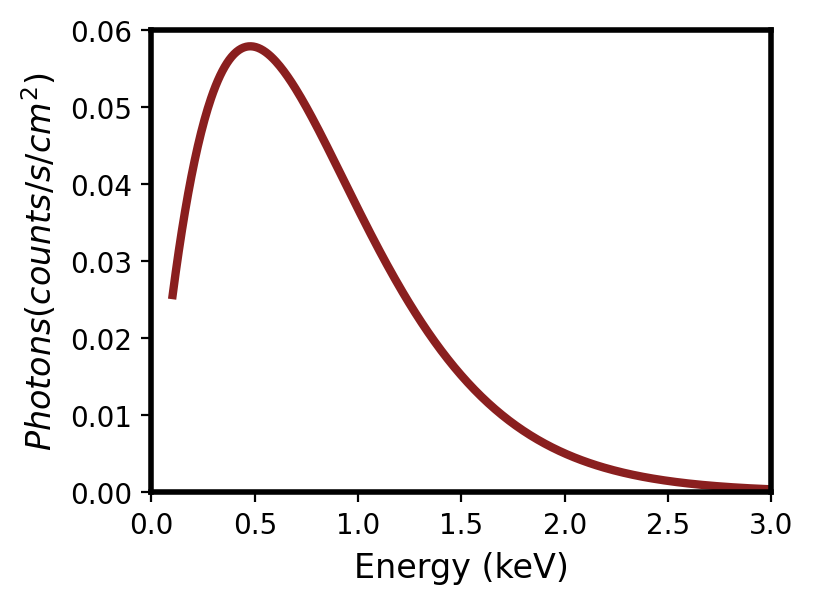

In [26]:
# Calculate the blackbody spectrum

kT = 0.3  # Temperature in keV
K = 1e-3  # Normalization factor in photons/cm²/s/keV
bb_spectrum = bbody(energies, kT, K)


# plot to see everything is ok

plt.figure(figsize=(4, 3))
plt.plot(energies, bb_spectrum)

plt.xlabel('Energy (keV)', fontsize=12)
plt.ylabel(r'$Photons (counts/s/cm^2)$', fontsize=12)


plt.axis([0, 3, 0, 0.06])

In [27]:
# Apply the RMF first on the bb spectrum, and then convolve the result with the ARF

affected_channel_energies, total_photons_detector = AggregateResponse(energies, bb_spectrum)
arf_arr = arf_interpolated(affected_channel_energies)



matrix vals [1.79738909e-01 1.73286557e-01 1.56125888e-01 1.27608120e-01
 8.90687928e-02 5.41549101e-02 2.95820460e-02 1.50207300e-02
 7.26246508e-03 3.43319681e-03 1.61752698e-03 7.70331826e-04
 3.74057854e-04 1.85924946e-04 9.46454093e-05 4.92773688e-05
 2.61876103e-05 1.41763985e-05 7.79021411e-06 4.35846277e-06
 2.47680441e-06 1.42716021e-06 8.33418596e-07 4.92156289e-07
 2.94742193e-07 1.79081923e-07 1.10118741e-07 6.83419685e-08
 4.30095284e-08 2.74146714e-08 1.76339459e-08 1.14659793e-08
 7.55477192e-09 5.01499287e-09 3.36723671e-09 2.28642860e-09
 1.56093471e-09 1.08071374e-09]
matrix vals [1.34434313e-01 1.40109867e-01 1.36657268e-01 1.25049561e-01
 1.06243603e-01 7.81488642e-02 4.96659130e-02 2.81428453e-02
 1.45787606e-02 7.11120386e-03 3.34638171e-03 1.55153661e-03
 7.20702461e-04 3.39361723e-04 1.63093908e-04 8.02154682e-05
 4.03711347e-05 2.07577978e-05 1.08610775e-05 5.79873677e-06
 3.14907834e-06 1.73544220e-06 9.69738608e-07 5.48042806e-07
 3.14222603e-07 1.82849817e-0

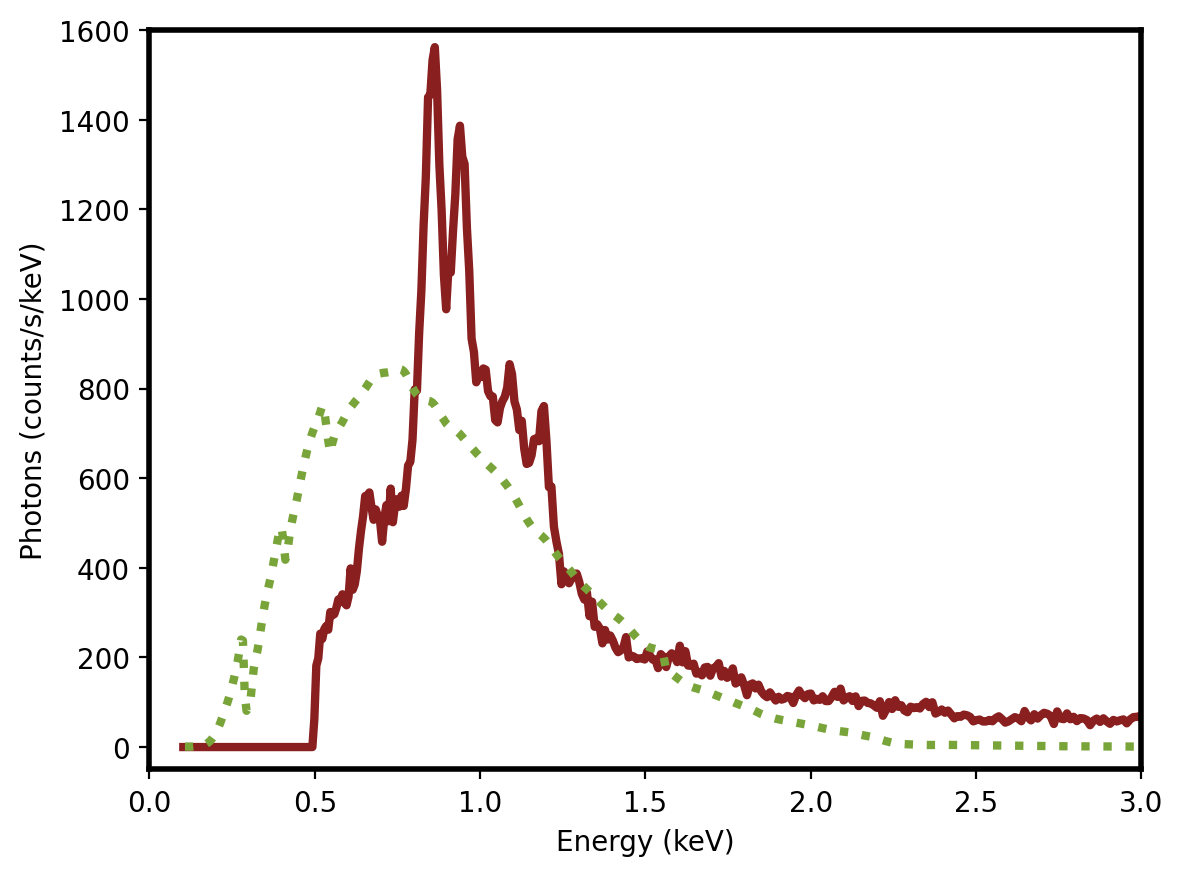

In [32]:
# Plot the observed spectrum and then bb x RMF x ARF
plt.plot(energies, rate_per_keV, label='Obs', color=cols_default[0])
plt.plot(affected_channel_energies, total_photons_detector * arf_arr, label=f'BB + RM + ARF', color=cols_default[1], linestyle='dotted')


plt.xlabel('Energy (keV)')
plt.ylabel('Photons (counts/s/keV)')

plt.axis([0, 3, -50, 1600])


plt.show()

In [63]:
# Calculate the blackbody spectrum
kT = 0.3  # Temperature in keV
K = 2e-1  # Normalization factor in photons/cm²/s/keV
bb_spectrum = bbody(energies, kT, K)
affected_channel_energies, total_photons_detector2 = AggregateResponse2(energies, bb_spectrum)


# Plot the observed spectrum
plt.plot(energies, rate_per_keV, label='Obs', color=cols_default[0])


plt.plot(affected_channel_energies, total_photons_detector2 * arf_arr, label=f'BB + RM + ARF', color=cols_default[1], linestyle='dotted')

plt.axis([0, 3, -50, 1600])



IndexError: invalid index to scalar variable.

# APEC model

Here I start to play with the APEC model. This models describes the emission spectrum from a hot, diffuse gas. APEC stands for "Astrophysical Plasma Emission Code", and in principle takes into account a variety of physical processes such as thermal bremsstrahlung, recombination, and line emission from ions:

Thermal Bremsstrahlung: Emission from free electrons being decelerated in the electric fields of ions.

Recombination: Emission lines produced when free electrons are captured by ions.

Line Emission: Emission lines from transitions between energy levels in ions.

Continuum Emission: Includes bremsstrahlung and two-photon emission processes.

We use the database ATOMDB (Astrophysical Plasma Emission Database) in order to compute this. 

In [4]:
import os

# Set the ATOMDB environment variable
os.environ['ATOMDB'] = '/Users/andreacaputo/atomdb'

# Verify it just to be sure
print("ATOMDB environment variable is set to:", os.environ['ATOMDB'])


ATOMDB environment variable is set to: /Users/andreacaputo/atomdb


In [5]:
import pyatomdb

In [6]:
# declare the Collisional Ionization Equilibrium session
sess = pyatomdb.spectrum.CIESession()


/var/folders/19/gw63c49d5ns7rcfbl2csybn00000gn/T/ipykernel_62231/1438879635.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Text(0, 0.5, 'Intensity (ph cm$^5$ s$^{-1}$ bin$^{-1}$)')

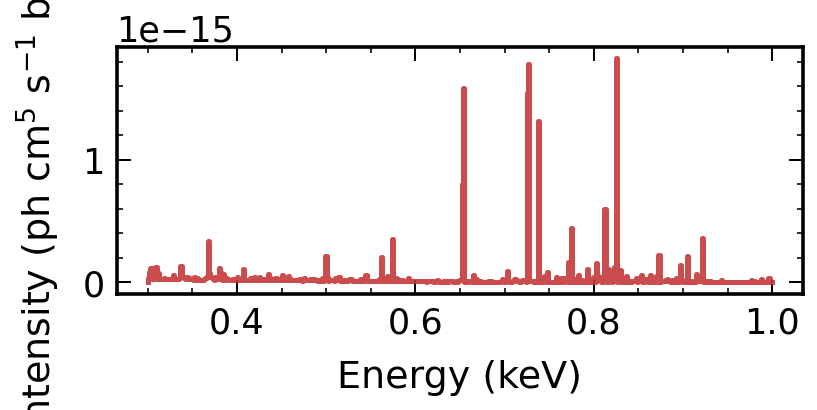

In [7]:
# create a set of energy bins (in keV) for the response. Note these are
# the n edges of the n-1 bins.
ebins = np.linspace(0.3,1.0,500)

# set the response (raw keyword tells pyatomdb it is not a real response file)
sess.set_response(ebins, raw=True)

kT = 0.4 # temperature in keV
spec = sess.return_spectrum(kT)

# we now have a spectrum and the energy bins,

# prepend a zero to the spectrum so that energy bins and spectrum have
# the same length. If you use a different plotting system you may
# need to add this to the end.
spec = np.append(0, spec)

# Returned spectrum has units of photons cm^5 s^-1 bin^-1
fig = pylab.figure()
fig.show()
ax = fig.add_subplot(211)
ax.plot(sess.ebins_out, spec, drawstyle='steps', label='dummy response')

# label the figure
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Intensity (ph cm$^5$ s$^{-1}$ bin$^{-1}$)')


In [46]:
# Path to your RMF file
rmf_path = '/Users/andreacaputo/Dropbox/Mac (2)/Desktop/PhysicsFolder/eRositaXray/Spectra_irfs_v3/tm1_rmf_141103v02.fits'
arf_file = '/Users/andreacaputo/Dropbox/Mac (2)/Desktop/PhysicsFolder/eRositaXray/Spectra_irfs_v3/tm1_arf_filter_000101v02.fits'

# Load the RMF file
rmf_hdul = fits.open(rmf_path)
ebounds = Table(rmf_hdul['EBOUNDS'].data)
matrix = Table(rmf_hdul['MATRIX'].data)

# Extract energy bounds from RMF
energy_lo = ebounds['E_MIN']
energy_hi = ebounds['E_MAX']
energy_bins = np.concatenate((energy_lo, [energy_hi[-1]]))




Notice that pyatomdb uses these files to convolve the intrinsic spectrum of the source with the instrument response, giving us the observed spectrum.

# An example with 2 different temperatures 

In [30]:
# Define the dictionary of element abundances for the specified elements (all set to 1 by default)

abundances = {"H": 1.0, "He": 1.0, "C": 1.0, "N": 1.0, "O": 1.0, "Ne": 1.0, "Mg": 1.0, "Al": 1.0, "Si": 1.0, "S": 1.0, "Ar": 1.0, "Ca": 1.0, "Fe": 1.0, "Ni": 1.0}

# Dictionary to map element symbols to atomic numbers

element_to_atomic_number = {"H": 1, "He": 2, "Li": 3, "Be": 4, "B": 5, "C": 6, "N": 7, "O": 8, "F": 9, "Ne": 10, "Na": 11, "Mg": 12, "Al": 13, "Si": 14, "P": 15, "S": 16, "Cl": 17, "Ar": 18, "K": 19, "Ca": 20, "Sc": 21, "Ti": 22, "V": 23, "Cr": 24, "Mn": 25, "Fe": 26, "Co": 27, "Ni": 28, "Cu": 29, "Zn": 30}

# Convert the elements and abundances to the appropriate format
elements = []
abundances_list = []
for element, abundance in abundances.items():
    atomic_number = element_to_atomic_number[element]
    elements.append(atomic_number)
    abundances_list.append(abundance)

In [34]:
# Let's do a couple of plots (different temperatures) as example

kT = 0.21 # temperature in keV
kT1 = 0.89 # temperature in keV

# declare the Collisional Ionization Equilibrium session
sess = pyatomdb.spectrum.CIESession()

# set the response!
sess.set_response(rmf_path, arf=arf_file)

# Set the abundances using the set_abund method


sess.set_abundset(abundstring='AG89') #Sets the baseline abundance values for all elements according 
#to the specified abundance set. In this case, AG89 is Anders & Grevesse (1989) https://ui.adsabs.harvard.edu/abs/1989GeCoA..53..197A/abstract

#sess.set_abundset('Lodd09') # Another example, Lodders (2009)



sess.set_abund(elements, abundances_list)

# return the final spectra to plot
apec_arr = sess.return_spectrum(kT)
apec_arr1 = sess.return_spectrum(kT1)




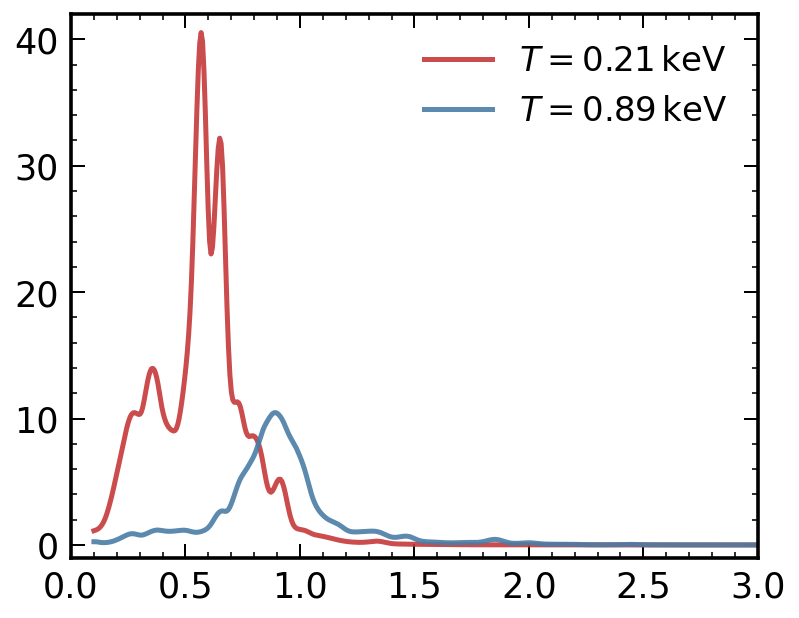

In [44]:
plt.plot(energy_lo, apec_arr * 1e15, color=cols_default[0], label =r'$T = 0.21 \, \rm keV$')
plt.plot(energy_lo, apec_arr1 * 1e15/4, color=cols_default[1], label =r'$T = 0.89 \, \rm keV$')

plt.axis([0, 3, -1, 42])

plt.legend()



In [33]:
sess.set_abundset(abundstring='ASL') # just to check which ones are available

Invalid Abundance Set chosen: select from: 
      Allen
       AG89
       GA88
    Feldman
    Uniform
       GA10
     Lodd09


TypeError: 'int' object is not subscriptable

# Try to understand the peaks

Here I try to understand the peaks, using the atomic database https://physics.nist.gov/PhysRefData/ASD/lines_form.html

In [50]:
import os
import pyatomdb
import matplotlib.pyplot as plt


# Temperature in keV
kT = 0.21


# Declare the Collisional Ionization Equilibrium session
sess = pyatomdb.spectrum.CIESession()

# Set the response (raw keyword tells pyatomdb it is not a real response file)
sess.set_response(rmf_path, arf=arf_file)

# Set the abundance set to AG89
sess.set_abundset('AG89')
sess.set_abund(elements, abundances_list)

# Generate spectrum for the specified temperature
apec_arr = sess.return_spectrum(kT)


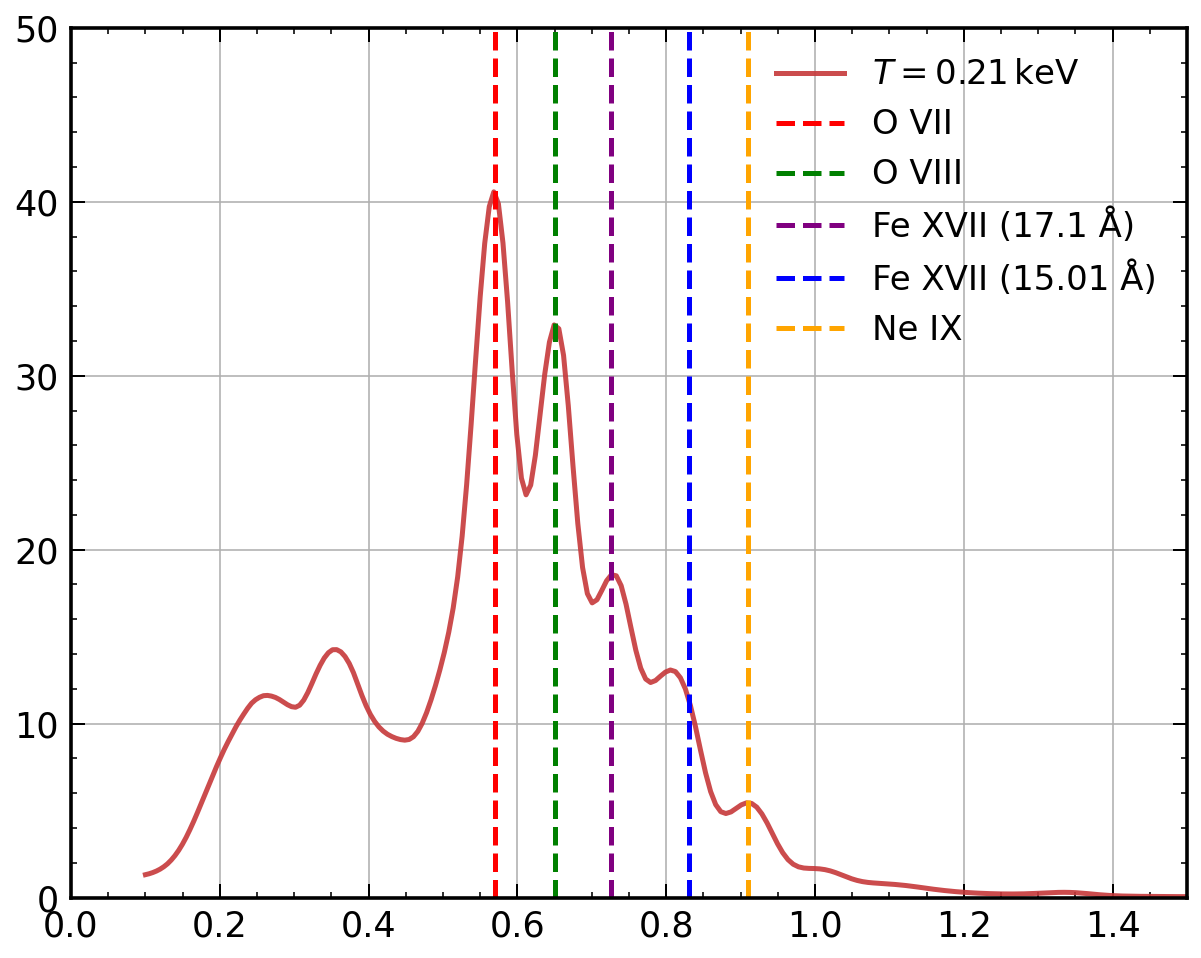

In [58]:
plt.figure(figsize=(10, 8))
plt.plot(energy_lo, apec_arr * 1e15, color=cols_default[0], label =r'$T = 0.21 \, \rm keV$')



# Annotate expected peaks
plt.axvline(x=0.57, color='red', linestyle='--', label='O VII')
plt.axvline(x=0.65, color='green', linestyle='--', label='O VIII')
plt.axvline(x=0.726, color='purple', linestyle='--', label='Fe XVII (17.1 Å)')
plt.axvline(x=0.83, color='blue', linestyle='--', label='Fe XVII (15.01 Å)')
plt.axvline(x=0.91, color='orange', linestyle='--', label='Ne IX')

# Setting axis limits
plt.axis([0, 1.5, 0, 50])

# Display the legend
plt.legend()

# Show grid for better readability
plt.grid(True)

# Show the plot
plt.show()